<a href="https://colab.research.google.com/github/Shiv-Sai20111018/eos-ai-workshop/blob/main/Week%203%20HW%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [12]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

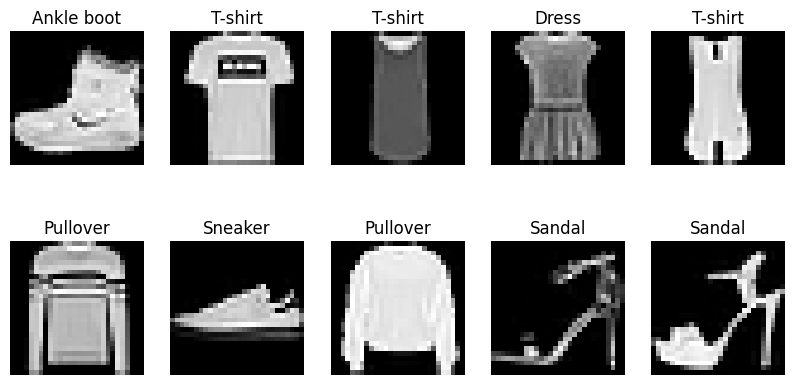

In [13]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot']

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')

plt.show()

In [14]:
model = models.Sequential([

    layers.Reshape((28,28,1), input_shape=(28,28)),

    # Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    validation_split=0.1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.8906 - loss: 0.3030 - val_accuracy: 0.9088 - val_loss: 0.2370
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9011 - loss: 0.2750 - val_accuracy: 0.9127 - val_loss: 0.2297
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9090 - loss: 0.2547 - val_accuracy: 0.9197 - val_loss: 0.2213
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9143 - loss: 0.2368 - val_accuracy: 0.9218 - val_loss: 0.2128
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9177 - loss: 0.2284 - val_accuracy: 0.9248 - val_loss: 0.2153
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9212 - loss: 0.2143 - val_accuracy: 0.9217 - val_loss: 0.2038
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9250 - loss: 0.2063 - val_accuracy: 0.9323 - val_loss: 0.1854
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9281 - loss: 0.1961 -

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9389 - loss: 0.2386
Test Accuracy: 0.9388999938964844


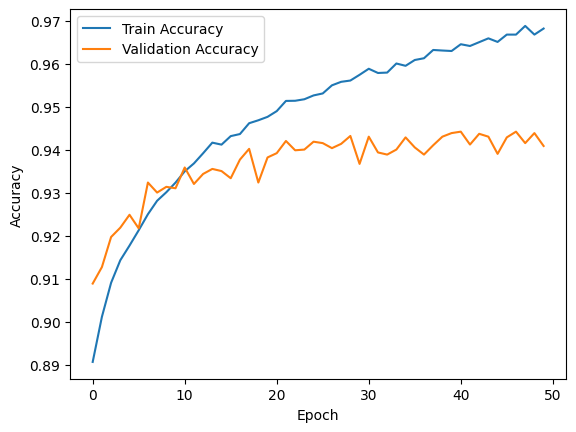

In [18]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


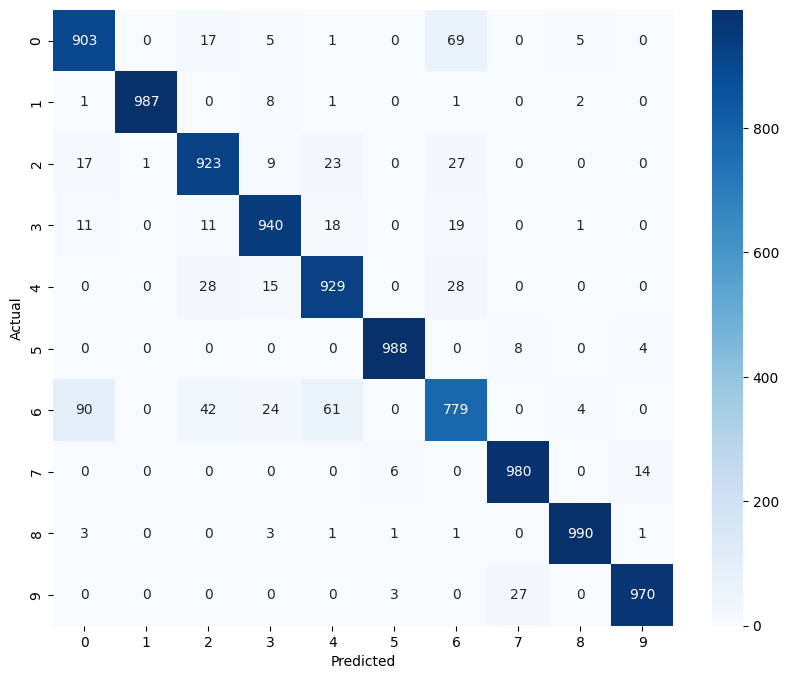

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

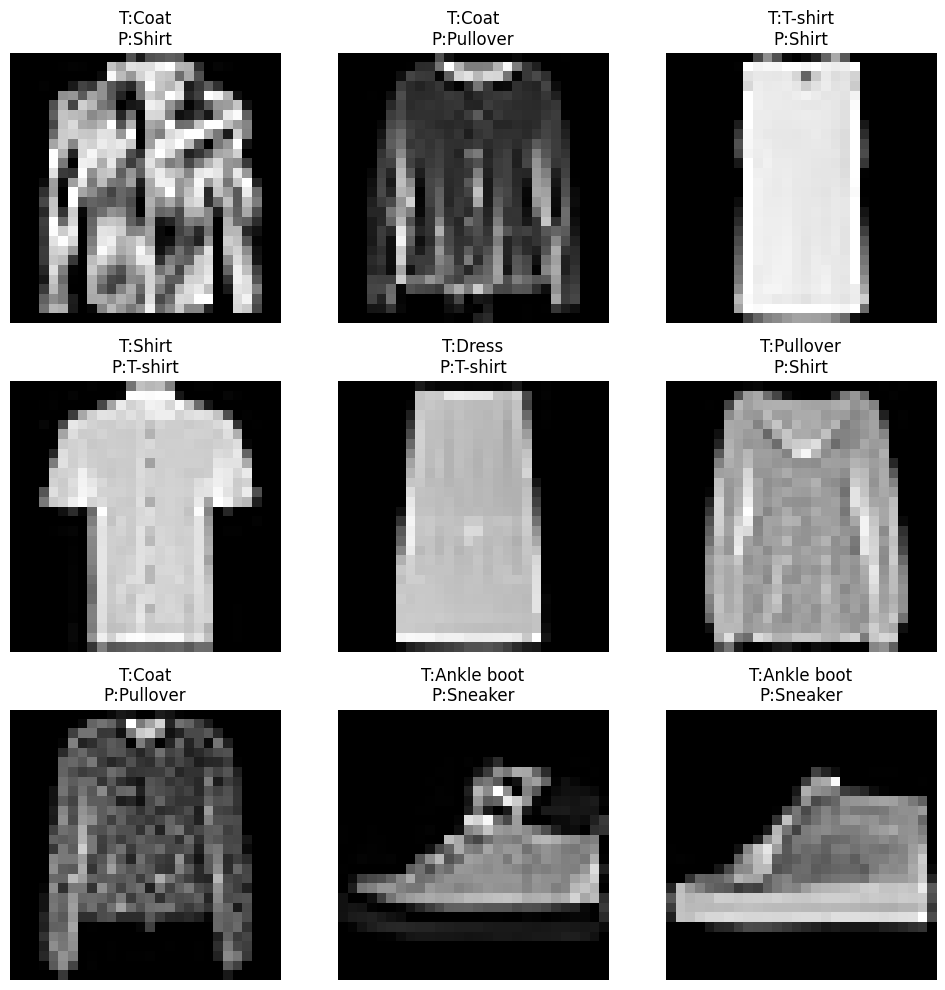

In [20]:
wrong = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,10))

for i, idx in enumerate(wrong[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[idx], cmap='gray')

    plt.title(
        f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()